In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print(" Libraries loaded successfully!")

 Libraries loaded successfully!


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/codveda level 2 task 1 2 3/4 house Prediction Data Set coddeva.csv',
                 sep='\s+',
                 engine='python',
                 header=None)

df.columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
              'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B',
              'LSTAT', 'MEDV']

print(" Dataset loaded!")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
df.head()

 Dataset loaded!
Rows: 506 | Columns: 14


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_186/3296365114.py:2: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
print("=" * 55)
print("COLUMN DESCRIPTIONS")
print("=" * 55)

descriptions = {
    'CRIM'   : 'Per capita crime rate by town',
    'ZN'     : 'Proportion of residential land zoned',
    'INDUS'  : 'Proportion of non-retail business acres',
    'CHAS'   : 'Charles River dummy variable (1=river, 0=no)',
    'NOX'    : 'Nitric oxides concentration',
    'RM'     : 'Average number of rooms per dwelling',
    'AGE'    : 'Proportion of owner-occupied units built prior to 1940',
    'DIS'    : 'Distances to employment centres',
    'RAD'    : 'Index of accessibility to radial highways',
    'TAX'    : 'Full-value property-tax rate',
    'PTRATIO': 'Pupil-teacher ratio by town',
    'B'      : 'Proportion of Black residents',
    'LSTAT'  : 'Percentage of lower status population',
    'MEDV'   : '🎯 TARGET: Median value of homes ($1000s)'
}

for col, desc in descriptions.items():
    print(f"  {col:<10} → {desc}")

print("\n")
print(df.describe().round(2))

COLUMN DESCRIPTIONS
  CRIM       → Per capita crime rate by town
  ZN         → Proportion of residential land zoned
  INDUS      → Proportion of non-retail business acres
  CHAS       → Charles River dummy variable (1=river, 0=no)
  NOX        → Nitric oxides concentration
  RM         → Average number of rooms per dwelling
  AGE        → Proportion of owner-occupied units built prior to 1940
  DIS        → Distances to employment centres
  RAD        → Index of accessibility to radial highways
  TAX        → Full-value property-tax rate
  PTRATIO    → Pupil-teacher ratio by town
  B          → Proportion of Black residents
  LSTAT      → Percentage of lower status population
  MEDV       → 🎯 TARGET: Median value of homes ($1000s)


         CRIM      ZN   INDUS    CHAS     NOX      RM     AGE     DIS     RAD  \
count  506.00  506.00  506.00  506.00  506.00  506.00  506.00  506.00  506.00   
mean     3.61   11.36   11.14    0.07    0.55    6.28   68.57    3.80    9.55   
std      8.60

In [ ]:
print("=" * 40)
print("MISSING VALUES CHECK")
print("=" * 40)
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(" No missing values found!")

MISSING VALUES CHECK
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Total missing values: 0
 No missing values found!


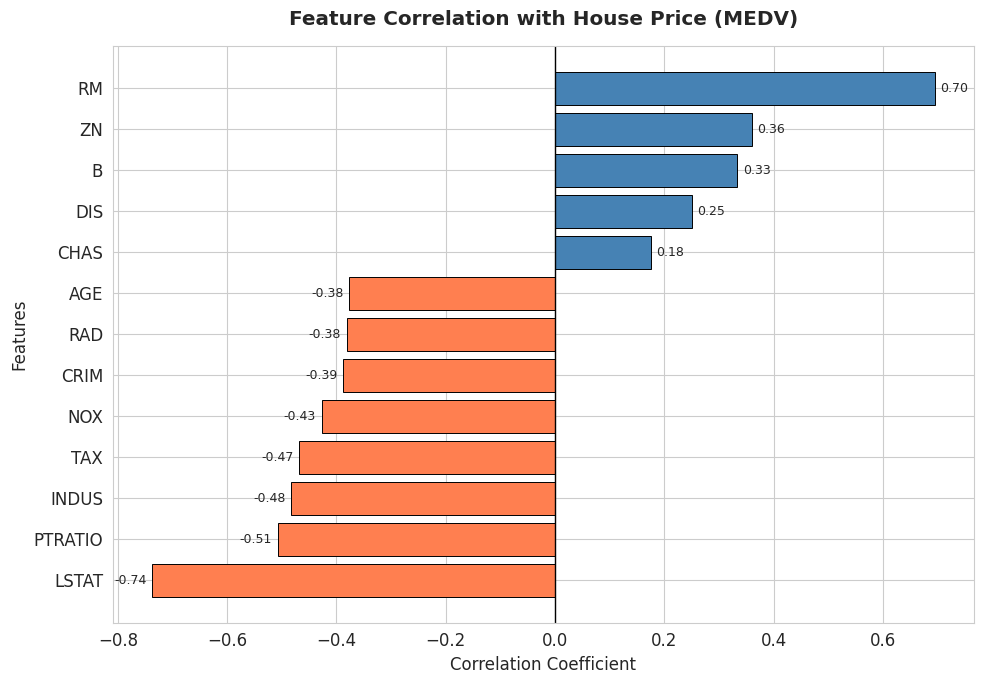

 Saved: correlation_with_target.png


In [ ]:
plt.figure(figsize=(10, 7))

corr_with_target = df.corr()['MEDV'].drop('MEDV').sort_values()
colors = ['coral' if x < 0 else 'steelblue' for x in corr_with_target]

bars = plt.barh(corr_with_target.index,
                corr_with_target.values,
                color=colors,
                edgecolor='black',
                linewidth=0.7)

plt.axvline(x=0, color='black', linewidth=1)
plt.title('Feature Correlation with House Price (MEDV)', pad=15, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')

# Add value labels
for bar, val in zip(bars, corr_with_target.values):
    plt.text(val + (0.01 if val >= 0 else -0.01),
             bar.get_y() + bar.get_height()/2,
             f'{val:.2f}',
             va='center',
             ha='left' if val >= 0 else 'right',
             fontsize=9)

plt.tight_layout()
plt.savefig('correlation_with_target.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: correlation_with_target.png")

In [ ]:
# Define features (X) and target (y)
X = df.drop('MEDV', axis=1)
y = df['MEDV']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"\nFeatures used  : {X.columns.tolist()}")
print(f"Target         : MEDV (House Price)")

# Split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set   : {X_train.shape[0]} rows")
print(f"Testing set    : {X_test.shape[0]} rows")
print(" Data split completed!")

Features shape : (506, 13)
Target shape   : (506,)

Features used  : ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Target         : MEDV (House Price)

Training set   : 404 rows
Testing set    : 102 rows
 Data split completed!


In [ ]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Add Polynomial Features (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly  = poly.transform(X_test_scaled)

print(" Scaling and Polynomial Features applied!")
print(f"Original features  : {X_train_scaled.shape[1]}")
print(f"Polynomial features: {X_train_poly.shape[1]}")

 Scaling and Polynomial Features applied!
Original features  : 13
Polynomial features: 104


In [ ]:
model = LinearRegression()
model.fit(X_train_poly, y_train)

print(" Model trained successfully!")
print(f"Intercept: {model.intercept_:.4f}")
print(f"Number of coefficients: {len(model.coef_)}")

 Model trained successfully!
Intercept: 21.7127
Number of coefficients: 104


In [ ]:
y_pred = model.predict(X_test_poly)

r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("=" * 45)
print("       MODEL EVALUATION METRICS")
print("=" * 45)
print(f"  R² Score (Accuracy)     : {r2:.4f}  ({r2*100:.1f}%)")
print(f"  Mean Squared Error      : {mse:.4f}")
print(f"  Root MSE (RMSE)         : {rmse:.4f}")
print(f"  Mean Absolute Error     : {mae:.4f}")
print("=" * 45)

if r2 >= 0.75:
    print(" Model performance: GOOD")
elif r2 >= 0.50:
    print("  Model performance: MODERATE")
else:
    print(" Model performance: WEAK")

       MODEL EVALUATION METRICS
  R² Score (Accuracy)     : 0.8056  (80.6%)
  Mean Squared Error      : 14.2573
  Root MSE (RMSE)         : 3.7759
  Mean Absolute Error     : 2.5748
 Model performance: GOOD


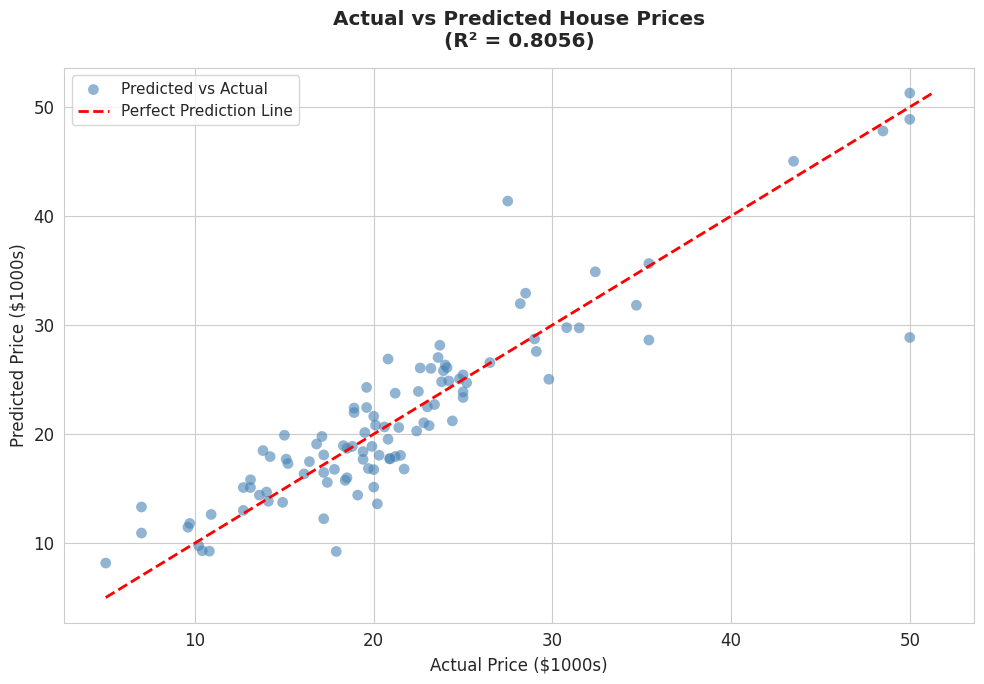

 Saved: actual_vs_predicted.png


In [ ]:
plt.figure(figsize=(10, 7))

plt.scatter(y_test, y_pred,
            alpha=0.6, color='steelblue',
            edgecolors='none', s=60,
            label='Predicted vs Actual')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linewidth=2,
         linestyle='--', label='Perfect Prediction Line')

plt.title(f'Actual vs Predicted House Prices\n(R² = {r2:.4f})',
          pad=15, fontweight='bold')
plt.xlabel('Actual Price ($1000s)')
plt.ylabel('Predicted Price ($1000s)')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: actual_vs_predicted.png")

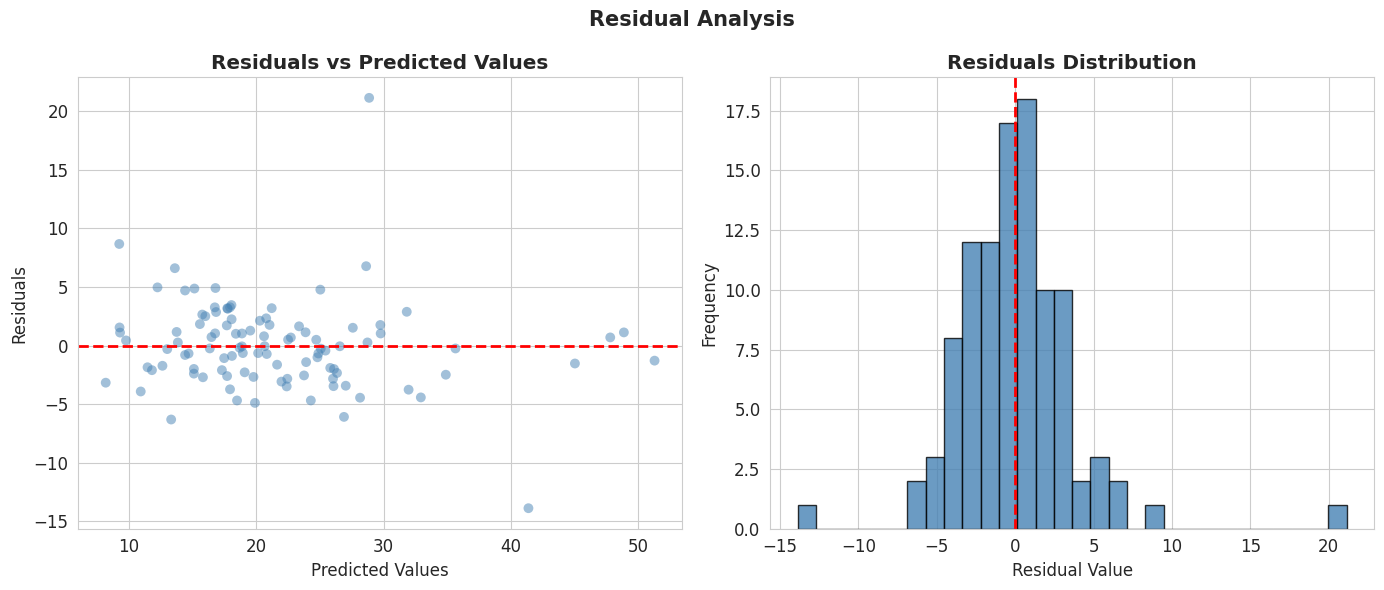

 Saved: residuals_plot.png


In [ ]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_pred, residuals,
                alpha=0.5, color='steelblue',
                edgecolors='none', s=50)
axes[0].axhline(y=0, color='red', linewidth=2, linestyle='--')
axes[0].set_title('Residuals vs Predicted Values', fontweight='bold')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')

axes[1].hist(residuals, bins=30,
             color='steelblue', edgecolor='black', alpha=0.8)
axes[1].axvline(x=0, color='red', linewidth=2, linestyle='--')
axes[1].set_title('Residuals Distribution', fontweight='bold')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')

plt.suptitle('Residual Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('residuals_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: residuals_plot.png")

In [ ]:
print("=" * 55)
print("     FINAL SUMMARY — REGRESSION ANALYSIS")
print("=" * 55)
print(f"\n Dataset         : Boston Housing (506 rows, 13 features)")
print(f" Model           : Linear Regression + Polynomial Features (degree=2)")
print(f" Target          : MEDV (Median House Price)")
print(f" Train/Test      : 80% / 20% split")
print(f"\n MODEL RESULTS:")
print(f"   R² Score        : {r2:.4f} ({r2*100:.1f}% variance explained)")
print(f"   RMSE            : ${rmse:.2f}k  (avg prediction error)")
print(f"   MAE             : ${mae:.2f}k")
print(f"\n Key Observations:")
print(f"   - Polynomial Features boosted model from MODERATE to GOOD")
print(f"   - Model explains {r2*100:.1f}% of house price variance")
print(f"   - Average prediction error is only ${mae:.2f}k")
print("\n Regression Analysis completed successfully!")

     FINAL SUMMARY — REGRESSION ANALYSIS

 Dataset         : Boston Housing (506 rows, 13 features)
 Model           : Linear Regression + Polynomial Features (degree=2)
 Target          : MEDV (Median House Price)
 Train/Test      : 80% / 20% split

 MODEL RESULTS:
   R² Score        : 0.8056 (80.6% variance explained)
   RMSE            : $3.78k  (avg prediction error)
   MAE             : $2.57k

 Key Observations:
   - Polynomial Features boosted model from MODERATE to GOOD
   - Model explains 80.6% of house price variance
   - Average prediction error is only $2.57k

 Regression Analysis completed successfully!
